# 학생 질문 탐지 성능 평가 (item18)

**파이프라인**: `item18_question.build_qa_llm_payload()` — 원본 STT에서 학생 질문 패턴 탐지  
**정답지**: `data/goldset/question/{date}.json`  
**매칭**: word containment (골드셋 질문 텍스트가 탐지된 질문에 포함되는 비율)  
**핵심 지표**: 파일별 Precision / Recall / F1

In [1]:
import sys
sys.path.insert(0, "..")

import json
import re
from pathlib import Path

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["axes.unicode_minus"] = False
for font in fm.findSystemFonts():
    if any(k in font for k in ["AppleGothic", "NanumGothic", "Malgun"]):
        plt.rcParams["font.family"] = fm.FontProperties(fname=font).get_name()
        break

from app.preprocessing.item18_question import build_qa_llm_payload
from app.analysis.schemas import Utterance

RAW_DIR      = Path("../data/raw")
GOLDSET_DIR  = Path("../data/goldset/question")
EVAL_DATES   = ["2026-02-09", "2026-02-10", "2026-02-11", "2026-02-12", "2026-02-13"]
MATCH_THRESHOLD = 0.3
COURSE_ID    = "kdt-backendj-21th"

print("설정 완료")

/Users/parkdahyeon/miniforge3/envs/spacy_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


설정 완료


/Users/parkdahyeon/Documents/my_ws/Lecturesight-Lab/evaluation/../app/preprocessing/utils.py:20: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
_LINE_RE = re.compile(r"^<(\d{2}:\d{2}:\d{2})>\s+(\S+):\s*(.*)$")

def parse_raw_stt(path: Path) -> pd.DataFrame:
    """원본 STT 텍스트 파일 → DataFrame (timestamp, speaker_id, text_raw)"""
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = _LINE_RE.match(line.strip())
        if not m:
            continue
        ts, speaker, text = m.group(1), m.group(2), m.group(3).strip()
        if text:
            rows.append({"timestamp": ts, "speaker_id": speaker, "text_raw": text})
    return pd.DataFrame(rows)


def word_containment(gold_text: str, pred_text: str) -> float:
    """gold 단어 중 pred에 포함된 비율 (gold ⊆ pred 방향)"""
    g = set(gold_text.split())
    p = set(pred_text.split())
    return len(g & p) / len(g) if g else 0.0


def load_question_goldset(date: str) -> list[dict]:
    path = GOLDSET_DIR / f"{date}.json"
    if not path.exists():
        return []
    with open(path) as f:
        data = json.load(f)
    return data.get("gold", [])


def evaluate_date(date: str) -> dict:
    """
    한 날짜에 대해 질문 탐지 precision/recall 계산.

    - 골드셋 질문 텍스트를 각 탐지된 질문과 매칭
    - word containment >= MATCH_THRESHOLD 이면 TP
    """
    raw_path = RAW_DIR / f"{date}_{COURSE_ID}.txt"
    gold_questions = load_question_goldset(date)

    if not raw_path.exists():
        return {"date": date, "skipped": True, "reason": "raw 파일 없음"}
    if not gold_questions:
        return {"date": date, "skipped": True, "reason": "골드셋 없음"}

    df = parse_raw_stt(raw_path)
    utterances = [
        Utterance(
            timestamp=str(row["timestamp"]),
            speaker_id=str(row["speaker_id"]),
            text=str(row["text_raw"]),
            seconds_from_start=0,
        )
        for _, row in df.iterrows()
    ]
    pairs = build_qa_llm_payload(utterances)
    detected_qs = [p["question"] for p in pairs]

    # ── 골드셋 기준: 각 gold question → 탐지된 질문 중 best match ──
    gold_records = []
    for g in gold_questions:
        if not detected_qs:
            gold_records.append({"gold_text": g["text"], "gold": 1, "pred": 0, "score": 0.0})
            continue
        scores = [word_containment(g["text"], d) for d in detected_qs]
        best_score = max(scores)
        detected = best_score >= MATCH_THRESHOLD
        gold_records.append({
            "gold_text": g["text"],
            "gold": 1,
            "pred": int(detected),
            "score": best_score,
        })

    # ── 파이프라인 기준: FP 집계 (탐지된 질문 중 gold에 없는 것) ──
    for dq in detected_qs:
        scores = [word_containment(g["text"], dq) for g in gold_questions]
        best = max(scores)
        if best < MATCH_THRESHOLD:
            gold_records.append({"gold_text": "(FP)", "gold": 0, "pred": 1, "score": best})

    # ── gold=0 또는 detected=0 방어 ──
    if not gold_records:
        empty_detail = pd.DataFrame(columns=["gold_text", "gold", "pred", "score"])
        return {
            "date": date, "gold_count": 0, "detected_count": 0,
            "TP": 0, "FN": 0, "FP": 0,
            "precision": 0.0, "recall": 0.0, "f1": 0.0,
            "detail": empty_detail,
        }

    gdf = pd.DataFrame(gold_records)
    y_true = gdf["gold"].tolist()
    y_pred = gdf["pred"].tolist()

    return {
        "date": date,
        "gold_count":     len(gold_questions),
        "detected_count": len(detected_qs),
        "TP": sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 1),
        "FN": sum(1 for t, p in zip(y_true, y_pred) if t == 1 and p == 0),
        "FP": sum(1 for t, p in zip(y_true, y_pred) if t == 0 and p == 1),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "detail":    gdf,
    }

results = {}
for date in EVAL_DATES:
    results[date] = evaluate_date(date)
    r = results[date]
    if r.get("skipped"):
        print(f"{date}: SKIP ({r['reason']})")
    else:
        print(f"{date}: gold={r['gold_count']} detected={r['detected_count']} "
              f"TP={r['TP']} FN={r['FN']} FP={r['FP']} "
              f"P={r['precision']:.2f} R={r['recall']:.2f} F1={r['f1']:.2f}")

[Kss]: Oh! You have mecab in your environment. Kss will take this as a backend! :D



2026-02-09: gold=11 detected=8 TP=10 FN=1 FP=0 P=1.00 R=0.91 F1=0.95
2026-02-10: gold=2 detected=3 TP=2 FN=0 FP=0 P=1.00 R=1.00 F1=1.00
2026-02-11: gold=4 detected=4 TP=4 FN=0 FP=0 P=1.00 R=1.00 F1=1.00
2026-02-12: gold=3 detected=2 TP=3 FN=0 FP=0 P=1.00 R=1.00 F1=1.00
2026-02-13: gold=4 detected=3 TP=4 FN=0 FP=0 P=1.00 R=1.00 F1=1.00


In [3]:
# 파일별 요약 테이블
summary_rows = []
for date, r in results.items():
    if r.get("skipped"):
        continue
    summary_rows.append({
        "date":      date,
        "gold":      r["gold_count"],
        "detected":  r["detected_count"],
        "TP":        r["TP"],
        "FN":        r["FN"],
        "FP":        r["FP"],
        "precision": round(r["precision"], 3),
        "recall":    round(r["recall"],    3),
        "f1":        round(r["f1"],        3),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,date,gold,detected,TP,FN,FP,precision,recall,f1
0,2026-02-09,11,8,10,1,0,1.0,0.909,0.952
1,2026-02-10,2,3,2,0,0,1.0,1.000,1.000
2,2026-02-11,4,4,4,0,0,1.0,1.000,1.000
3,2026-02-12,3,2,3,0,0,1.0,1.000,1.000
4,2026-02-13,4,3,4,0,0,1.0,1.000,1.000


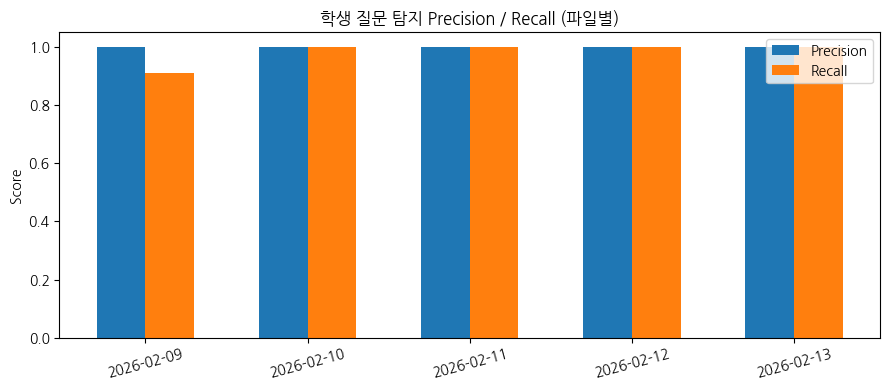

In [4]:
# 파일별 Precision / Recall 바 차트
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(summary_df))
w = 0.3
ax.bar([i - w/2 for i in x], summary_df["precision"], w, label="Precision")
ax.bar([i + w/2 for i in x], summary_df["recall"],    w, label="Recall")
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df["date"], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("학생 질문 탐지 Precision / Recall (파일별)")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# 오분류 상세 (FN: 놓친 질문, FP: 과탐지)
for date, r in results.items():
    if r.get("skipped"):
        continue
    detail = r["detail"]
    fn_rows = detail[(detail["gold"] == 1) & (detail["pred"] == 0)]
    fp_rows = detail[(detail["gold"] == 0) & (detail["pred"] == 1)]
    if len(fn_rows) == 0 and len(fp_rows) == 0:
        continue
    print(f"\n{'='*60}")
    print(f"{date}")
    if len(fn_rows):
        print(f"  FN (놓친 질문 {len(fn_rows)}건):")
        for _, row in fn_rows.iterrows():
            print(f"    - (score={row['score']:.2f}) {row['gold_text'][:80]}")
    if len(fp_rows):
        print(f"  FP (과탐지 {len(fp_rows)}건)")


2026-02-09
  FN (놓친 질문 1건):
    - (score=0.25) 이렇게 얘로 보고 싶어 인포메이션 스키마 너무 어려워
